# Demo of DISC tomography based on a simple model to provide an intutive comparison between 
# traveltime esitmated using eikonal wave equation and DISC

## Description
This notebook implements DISC based traveltime estimate and validate its accuracy by comparing the 
traveltime estimated using eikonal wave equation.  


## Author
Chao Li

## Date
2026-07

In [ ]:
#####Step1 import necessary package

import numpy as np
import matplotlib.pyplot as plt
import skfmm
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os

In [ ]:
#####Step2 loading real model
nx, ny = 50, 50
dx = dy = 0.1
v_low = 3000
v_high = 7000
v_true = v_low * np.ones((ny, nx))
Y, X = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')
r = 5
mask1 = (X - 25)**2 + (Y - 10)**2 <= r**2
mask2 = (X - 25)**2 + (Y - 30)**2 <= r**2
v_true[mask1] = v_high
v_true[mask2] = v_high
#########geometry setting
n_sources = 50
sources = [(0, (i*(ny-1)*dx/(n_sources-1))) for i in range(n_sources)] #### source locations (x,y)
n_receivers = 50
receivers = [((nx-1)*dx, (i*(ny-1)*dy/(n_receivers-1))) for i in range(n_receivers)] ###receiver locations (x,y)

In [3]:
#####Step3 build ray path matrix based on eikonal wave equation

sources_x=[ii[0] for ii in sources] ########x coordinates of sources
sources_y=[ii[1] for ii in sources] ########y coordinates of sources

receivers_x=[ii[0] for ii in receivers] ########x coordinates of receivers
receivers_y=[ii[1] for ii in receivers] ########y coordinates of receivers

address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)
figadd=address+'/Figure/'

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

###compute traveltime for each ray based on eikonal equation

traveltimes,ray_paths=compute_travel_times(v_true, sources, receivers, dx, dy, nx, ny)  ###compute traveltime and ray paths   


###build ray path matrix 
A=build_ray_matrix(ray_paths, dx, dy, nx, ny)

0.0014238091 0.0021125455


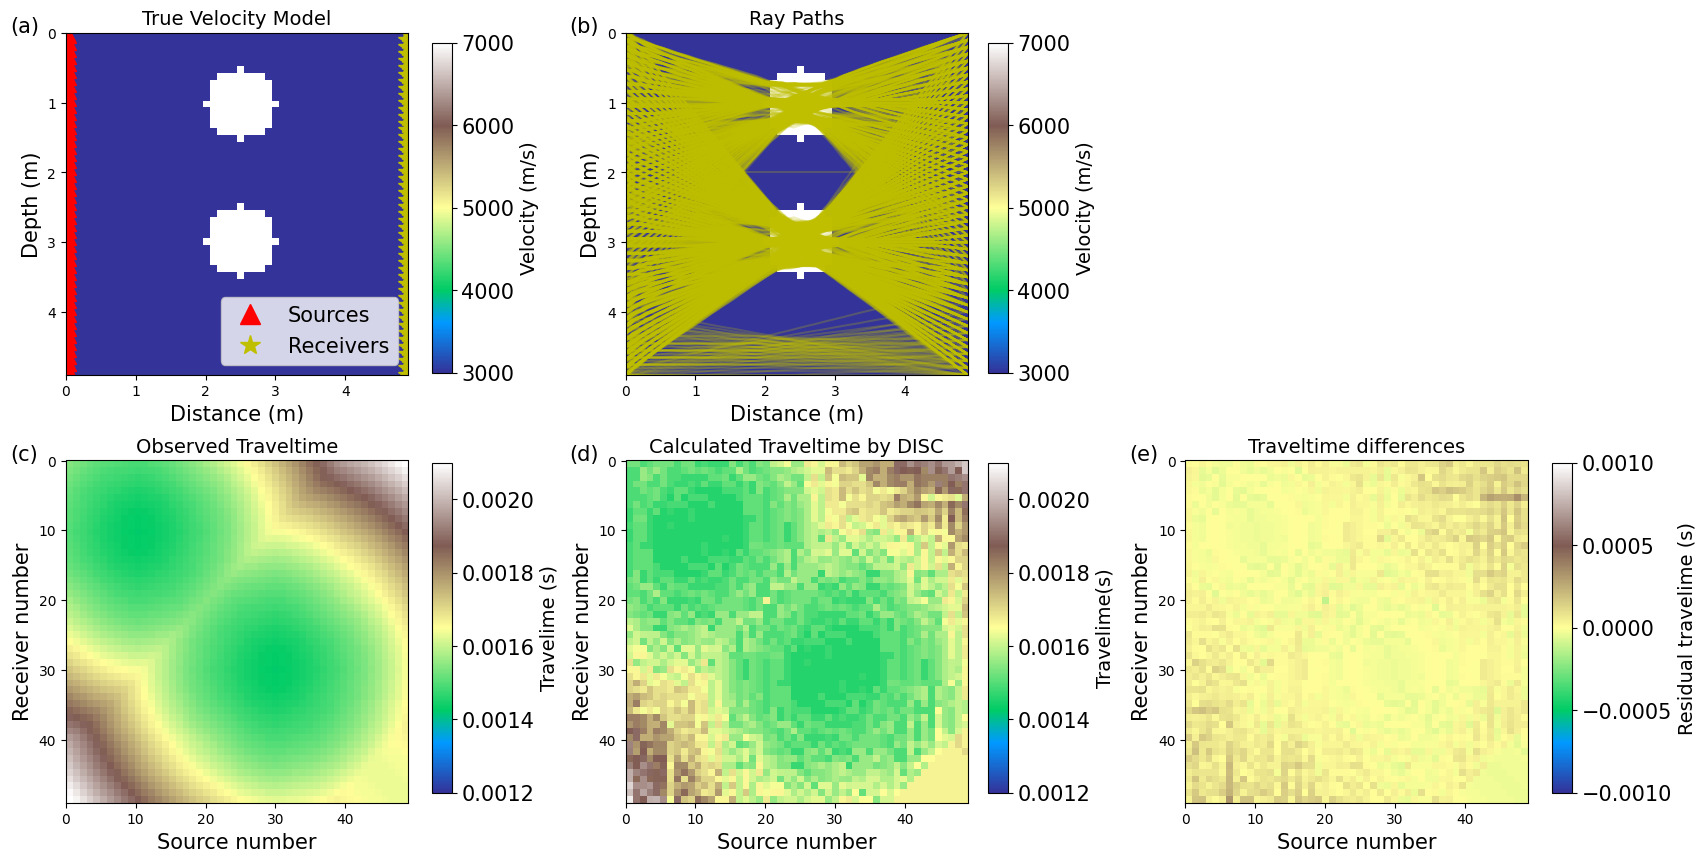

In [4]:
# ########Step 4 display the traveltime field and ray paths

time_eik=np.squeeze(traveltimes).reshape(ny, nx, order='C'); #traveltime estimated usig eikonal equation

time_cal=A.dot(1./v_true.reshape(nx*ny,1,order='C')).reshape(ny, nx) #### traveltime calculated using ray path matrix and true velocity model



print(time_eik.min(),time_eik.max())

v_low = 3000
v_hig = 7000

tlow=0.0012
thig=0.0021

vasp=1

fig, axes = plt.subplots(2, 3, figsize=(20,10))
for ii,ax in enumerate(axes.flatten()):
	if ii==0:
		im1=ax.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect=vasp)
		
		ax.set_ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-0.8,0, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.33, 0.54, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Velocity (m/s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.plot(sources_x,sources_y,'r^',  markersize=15)
		ax.plot(receivers_x,receivers_y,'y*',  markersize=15)
		ax.set_title('True Velocity Model', fontsize=14)
		ax.legend(['Sources','Receivers'],loc='lower right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})
			
	
		
	if ii==1:	
		im1=ax.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect=vasp)
		ax.set_ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-0.8,0, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.608, 0.54, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Velocity (m/s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		for ray_x, ray_y in ray_paths:
    			ax.plot(ray_x, ray_y, 'y-', alpha=0.25)
		ax.set_title('Ray Paths', fontsize=14)
		
	if ii==2:	
		ax.axis('off')
		
	if ii==3:	
		im1=ax.imshow(time_eik,cmap='terrain',vmin=tlow,vmax=thig,extent=[0,(nx-1),(ny-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.33, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Travelime (s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.set_title('Observed Traveltime', fontsize=14)
			
			
	if ii==4:	
		im1=ax.imshow(time_cal,cmap='terrain',vmin=tlow,vmax=thig,extent=[0,(nx-1),(ny-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.608, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Travelime(s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.set_title('Calculated Traveltime by DISC', fontsize=14)
	if ii==5:	
		im1=ax.imshow(time_eik-time_cal,cmap='terrain',vmin=-0.001,vmax=0.001,extent=[0,(nx-1),(ny-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(e)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')
		colorbar_position = [0.89, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Residual travelime (s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
			label.set_fontsize(15)
		ax.set_title('Traveltime differences', fontsize=14)
		

plt.subplots_adjust(hspace=0.25)	
plt.subplots_adjust(wspace=0.3)	
plt.savefig(figadd+"timecomp.png", dpi=300,bbox_inches='tight')	
plt.show()